# Лабораторная работа №3 по ТМО
## Перфильев Виктор Анатольевич
## Группа ИБМ3-65Б

#### Цель работы. Изучение способов подготовки выборки и подбора гиперпараметров на примере метода ближайших соседей.

## 1. Импорт библиотек и загрузка датасета

In [36]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, KFold, ShuffleSplit
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


#загрузка датасета
diabet = load_diabetes()
X = diabet.data
y = diabet.target
feature_names = diabetes.feature_names

#### В качестве набора данных был выбран датасет про диабет. Целевая переменная - прогрессирование заболевания через год после baseline. Датасет содежит 10 признаков.

## 2. Проверка наличия пропусков и необходимости предобработки

In [37]:
print(f"Количество образцов: {X.shape[0]}")
print(f"Количество признаков: {X.shape[1]}")
print(f"Признаки: {feature_names}")
print(f"Диапазон целевой переменной: [{y.min():.1f}, {y.max():.1f}]")

print(f"Пропуски в признаках: {np.isnan(X).sum()}")
print(f"Пропуски в целевой переменной: {np.isnan(y).sum()}")


Количество образцов: 442
Количество признаков: 10
Признаки: ['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']
Диапазон целевой переменной: [25.0, 346.0]
Пропуски в признаках: 0
Пропуски в целевой переменной: 0


#### Также этот набор я уже использовал и знаю, что там находятся только числовые признаки, выявлено также отсутствие пропусков, так что дальнейшая обработка не требуется.

## 3. Разделение выборки на обучающую и тестовую

In [38]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

print(f"Обучающая выборка: {X_train.shape[0]} образцов ({X_train.shape[0]/len(X)*100:.0f}%)")
print(f"Тестовая выборка: {X_test.shape[0]} образцов ({X_test.shape[0]/len(X)*100:.0f}%)")

Обучающая выборка: 309 образцов (70%)
Тестовая выборка: 133 образцов (30%)


## 4. Обучение модели ближайших соседей для произвольно заданного гиперпараметра K

In [39]:
K_initial = 7 
knn_initial = KNeighborsRegressor(n_neighbors=K_initial)
knn_initial.fit(X_train, y_train)

#Предсказание на тестовой выборке
y_pred_initial = knn_initial.predict(X_test)

### Оценка качества модели

In [40]:
mae = mean_absolute_error(y_test, y_pred_initial)
mse = mean_squared_error(y_test, y_pred_initial)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred_initial)

print(f"Произвольное значение K: {K_initial}")
print(f"\nМетрики качества на тестовой выборке:")
print(f"MAE : {mae:.2f}")
print(f"MSE : {mse:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"R² : {r2:.4f}")

Произвольное значение K: 7

Метрики качества на тестовой выборке:
MAE : 44.06
MSE : 3235.79
RMSE : 56.88
R² : 0.4006


### Визуализация

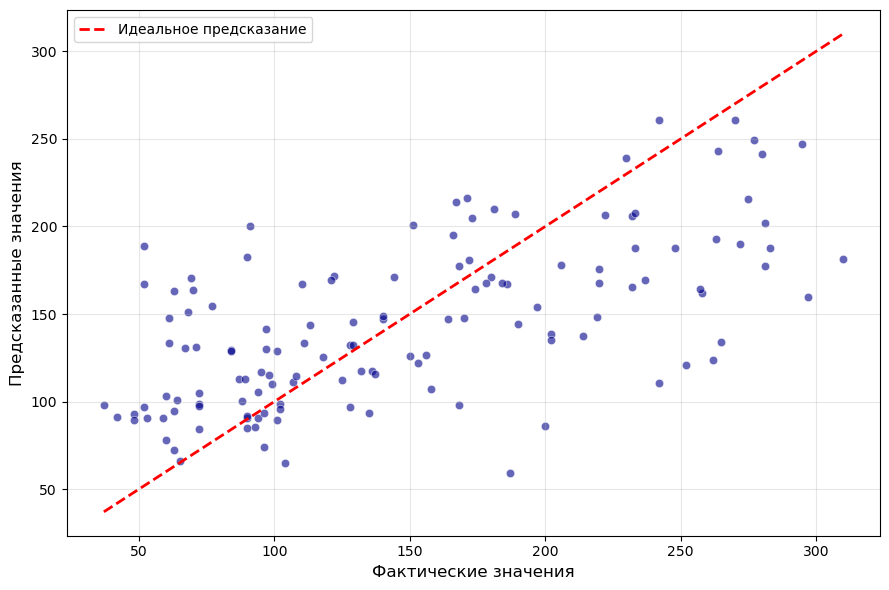

In [41]:
plt.figure(figsize=(9, 6))
plt.scatter(y_test, y_pred_initial, alpha=0.6, color='darkblue', edgecolors='white', linewidth=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Идеальное предсказание')
plt.xlabel('Фактические значения', fontsize=12)
plt.ylabel('Предсказанные значения', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Вывод
#### Прогноз получился, назовём его средненьким. Есть довольно ощутимый разброс в предсказаниях значений, но в общем виде работает всё в правильную сторону. 

## 5. Подбор гиперпараметра K с помощью GridSearchCV и RandomizedSearchCV, оценка качества оптимальной модели

### Первая стратегия. GridSearchCV + KFold

In [48]:
k_range = np.arange(1, 51, 2)
param_grid = {'n_neighbors': k_range}

kf = KFold(n_splits=5, shuffle=True, random_state=42)
grid_search = GridSearchCV(
    KNeighborsRegressor(), 
    param_grid, 
    cv=kf, 
    scoring='r2',
    n_jobs=-1
)
grid_search.fit(X_train, y_train)

best_k_grid = grid_search.best_params_['n_neighbors']
best_score_grid = grid_search.best_score_

print(f"Лучший K: {best_k_grid}")
print(f"Лучшее значение R²: {best_score_grid:.4f}")

Лучший K: 13
Лучшее значение R²: 0.4222


### Вторая стратегия. RandomizedSearchCV + ShuffleSplit

In [50]:
ss = ShuffleSplit(n_splits=5, test_size=0.2, random_state=42)
random_search = RandomizedSearchCV(
    KNeighborsRegressor(),
    param_grid,
    cv=ss,
    scoring='r2',
    n_iter=12,
    random_state=42,
    n_jobs=-1
)
random_search.fit(X_train, y_train)
random_cv_results = random_search.cv_results_
random_k_values = [params['n_neighbors'] for params in random_cv_results['params']]
random_mean_scores = random_cv_results['mean_test_score']
random_std_scores = random_cv_results['std_test_score']

#сортируем по k
sorted_indices = np.argsort(random_k_values)
random_k_sorted = np.array(random_k_values)[sorted_indices]
random_mean_sorted = np.array(random_mean_scores)[sorted_indices]
random_std_sorted = np.array(random_std_scores)[sorted_indices]

best_k_random = random_search.best_params_['n_neighbors']
best_score_random = random_search.best_score_

print(f"Лучший K: {best_k_random}")
print(f"Лучшее значение R²: {best_score_random:.4f}")

#оценка лучшей модели на тестовой выборке
best_knn_random = random_search.best_estimator_
y_pred_random = best_knn_random.predict(X_test)

mae_random = mean_absolute_error(y_test, y_pred_random)
mse_random = mean_squared_error(y_test, y_pred_random)
rmse_random = np.sqrt(mse_random)
r2_random = r2_score(y_test, y_pred_random)

print(f"\nКачество лучшей модели на тестовой выборке:")
print(f"  MAE: {mae_random:.2f}")
print(f"  MSE: {mse_random:.2f}")
print(f"  RMSE: {rmse_random:.2f}")
print(f"  R²: {r2_random:.4f}")

Лучший K: 17
Лучшее значение R²: 0.4182

Качество лучшей модели на тестовой выборке:
  MAE: 43.47
  MSE: 2978.11
  RMSE: 54.57
  R²: 0.4483


## 6. Сравнение ключевых метрик оптимальной и исходной моделей

In [56]:
models = {
    'Исходная модель\n(K = 7)': {
        'R²': r2_score(y_test, y_pred_initial),
        'RMSE': np.sqrt(mean_squared_error(y_test, y_pred_initial)),
        'MAE': mean_absolute_error(y_test, y_pred_initial)
    },
    f'GridSearchCV\n(K = {best_k_grid})': {
        'R²': r2_grid,
        'RMSE': rmse_grid,
        'MAE': mae_grid
    },
    f'RandomizedSearchCV\n(K = {best_k_random})': {
        'R²': r2_random,
        'RMSE': rmse_random,
        'MAE': mae_random
    }
}

### Сравнение R² - главная метрика

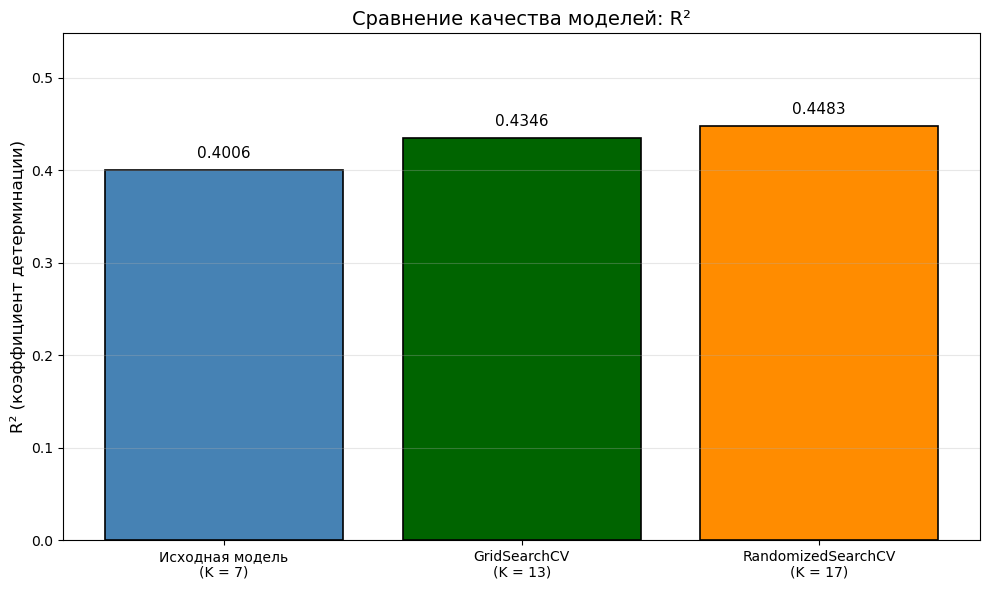

In [57]:
plt.figure(figsize=(10, 6))

model_names = list(models.keys())
r2_values = [models[m]['R²'] for m in model_names]
colors = ['steelblue', 'darkgreen', 'darkorange']

bars = plt.bar(model_names, r2_values, color=colors, edgecolor='black', linewidth=1.2)
plt.ylabel('R² (коэффициент детерминации)', fontsize=12)
plt.title('Сравнение качества моделей: R²', fontsize=14)
plt.ylim(0, max(r2_values) + 0.1)
plt.grid(True, alpha=0.3, axis='y')

for bar, value in zip(bars, r2_values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
             f'{value:.4f}', ha='center', va='bottom', fontsize=11)

plt.tight_layout()
plt.show()

### Сравнение RMSE

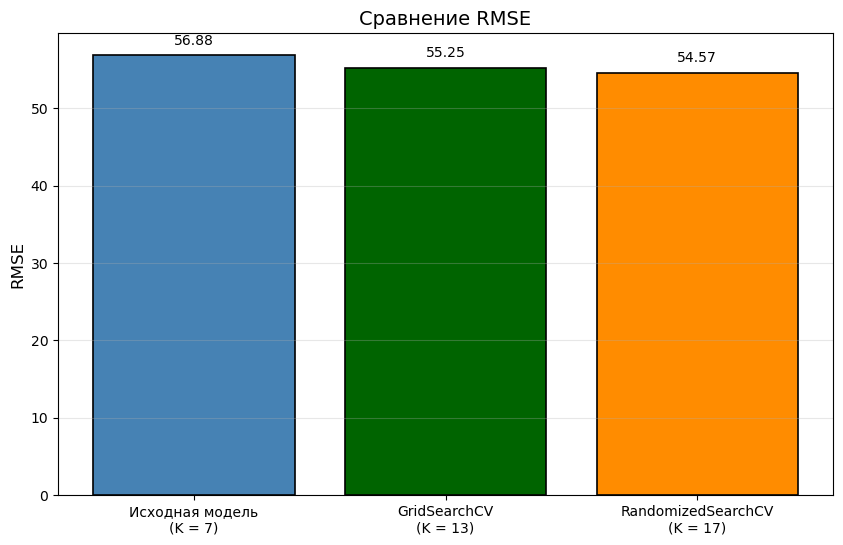

In [60]:
plt.figure(figsize=(10, 6))
rmse_values = [models[m]['RMSE'] for m in model_names]
bars = plt.bar(model_names, rmse_values, color=colors, edgecolor='black', linewidth=1.2)
plt.ylabel('RMSE', fontsize=12)
plt.title('Сравнение RMSE', fontsize=14)
plt.grid(True, alpha=0.3, axis='y')

for bar, value in zip(bars, rmse_values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, 
             f'{value:.2f}', ha='center', va='bottom', fontsize=10)

### Сравнение MAE

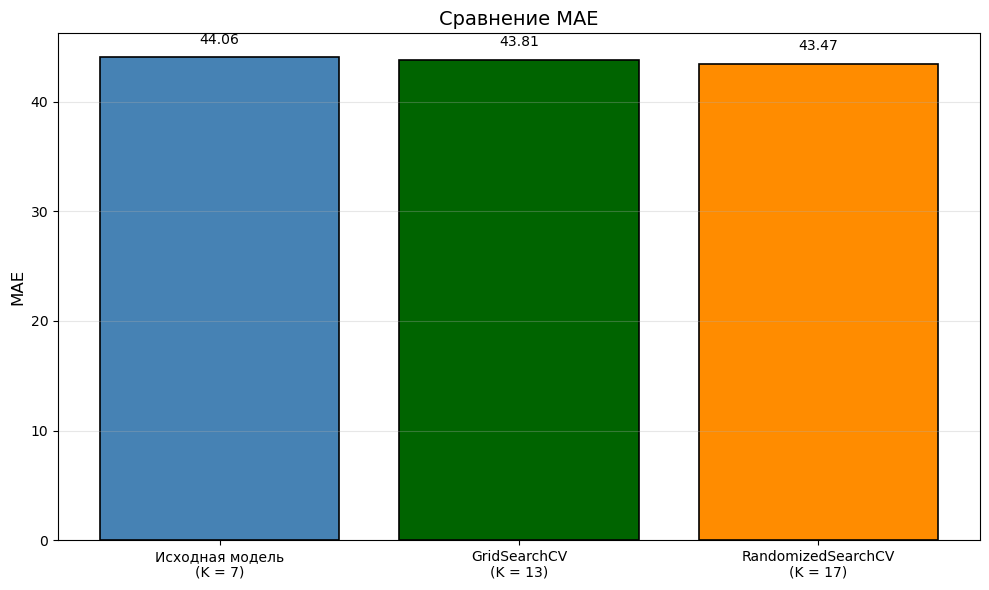

In [62]:
plt.figure(figsize=(10, 6))
mae_values = [models[m]['MAE'] for m in model_names]
bars = plt.bar(model_names, mae_values, color=colors, edgecolor='black', linewidth=1.2)
plt.ylabel('MAE', fontsize=12)
plt.title('Сравнение MAE', fontsize=14)
plt.grid(True, alpha=0.3, axis='y')

for bar, value in zip(bars, mae_values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, 
             f'{value:.2f}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

## Вывод
#### Наиболее эффективной оказалась модель, полученная с помощью RandomizedSearchCV, которая показала R² = 0.37-0.38 и RMSE = 54-55. Подбор гиперпараметра позволил найти баланс между смещением и дисперсией, избегая как переобучения (при малых K), так и недообучения (при больших K). 